In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset_raw = pd.read_csv('sri_lanka_irrigation_dataset.csv') 
print(f"Shape: {dataset_raw.shape} → {dataset_raw.shape[0]} records, {dataset_raw.shape[1]} features") 
pd.set_option('display.max_columns', None) 
dataset_raw.head()

Shape: (10000, 28) → 10000 records, 28 features


,Field_Cycle_ID,District,Climate_Zone,Season,Crop_Type,Crop_Growth_Stage,Stage_Duration_days,Soil_Type,Soil_pH,Soil_Moisture_pct,Organic_Carbon_pct,Electrical_Conductivity_dSm,Tmax_C,Tmin_C,Temperature_C,Humidity_pct,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Reference_ET0_mm_day,Crop_Coefficient_Kc,Net_Irrigation_Requirement_mm,Gross_Irrigation_Requirement_mm
0,0,Kalutara,Wet,Maha,Big Onion,Initial,15,Sandy Loam,5.95,15.20,0.89,0.46,28.8,22.6,25.7,85.5,105.3,6.4,5.3,Rainfed,Agro-well,0.92,Yes,13.2,3.77,0.70,0.0,NaN
1,0,Kalutara,Wet,Maha,Big Onion,Development,25,Sandy Loam,5.77,18.50,1.44,0.42,29.2,22.4,25.8,79.3,166.0,5.7,8.1,Rainfed,Agro-well,0.92,Yes,0.0,3.87,0.90,0.0,NaN
2,0,Kalutara,Wet,Maha,Big Onion,Mid-season,35,Sandy Loam,5.90,18.90,1.04,0.37,27.2,23.1,25.1,85.5,104.6,5.9,5.3,Rainfed,Agro-well,0.92,Yes,0.0,2.79,1.05,0.0,NaN
3,0,Kalutara,Wet,Maha,Big Onion,Late-season,20,Sandy Loam,5.85,17.53,0.54,0.44,28.1,22.7,25.4,84.5,112.9,6.2,8.4,Rainfed,Agro-well,0.92,Yes,0.0,3.09,0.75,0.0,NaN
4,1,Monaragala,Intermediate,Maha,Paddy (Rice),Initial,20,Sandy,4.75,9.17,0.42,0.50,29.3,20.3,24.8,80.3,102.6,5.8,9.7,Drip,Agro-well,1.63,No,62.4,4.43,1.05,2.8,3.1


In [3]:
# Drop both the target variable and the ID column at the start
df_raw = dataset_raw.drop(["Gross_Irrigation_Requirement_mm", "Field_Cycle_ID"], axis=1)

In [4]:
# ── 3B. Column-level quality overview ──────────────────────────────────────
def scan_data_quality(df):
    hidden_numeric, dirty_categorical = [], []
    for col in df.select_dtypes(include=['object', 'string']).columns:
        vals = df[col].dropna().unique()
        if vals.size == 0: continue
        
        if pd.to_numeric(pd.Series(vals), errors='coerce').notna().mean() > 0.5 and df[col].nunique() != len(df):
            hidden_numeric.append(col)
        elif vals.size != pd.Series(vals).astype(str).str.strip().nunique():
            dirty_categorical.append(col)
    return hidden_numeric, dirty_categorical

hidden_numeric_cols, dirty_cols_names = scan_data_quality(df_raw)

# Generate Quality Table
col_info = pd.DataFrame({
    'pandas_dtype' : df_raw.dtypes.astype(str),
    'null_count'   : df_raw.isna().sum(),
    'null_%'       : (df_raw.isna().mean() * 100).round(2),
    'n_unique'     : df_raw.nunique(),
    'sample_values': [str(df_raw[c].dropna().unique()[:3].tolist()) for c in df_raw.columns]
}).sort_values('null_%', ascending=False)

print("=== Column Quality Scan ===")
# Inline Row Styling based on row index name
display(col_info.style.apply(lambda row: 
    ['background-color: #ffe6e6'] * len(row) if row.name in hidden_numeric_cols else 
    ['background-color: #fff2cc'] * len(row) if row.name in dirty_cols_names else 
    [''] * len(row), axis=1))

if hidden_numeric_cols: print(f"• Hidden Numeric Columns (Red): {hidden_numeric_cols}")
if dirty_cols_names: print(f"• Dirty Categorical Columns (Yellow): {dirty_cols_names}")
if not hidden_numeric_cols and not dirty_cols_names:print("Wrong data types and dirty entries have been corrected.")

=== Column Quality Scan ===


,pandas_dtype,null_count,null_%,n_unique,sample_values
District,object,0,0.000000,25,"['Kalutara', 'Monaragala', 'Galle']"
Climate_Zone,object,0,0.000000,3,"['Wet', 'Intermediate', 'Dry']"
Season,object,0,0.000000,2,"['Maha', 'Yala']"
Crop_Type,object,0,0.000000,6,"['Big Onion', 'Paddy (Rice)', 'Tomato']"
Crop_Growth_Stage,object,0,0.000000,4,"['Initial', 'Development', 'Mid-season']"
Stage_Duration_days,int64,0,0.000000,11,"[15, 25, 35]"
Soil_Type,object,0,0.000000,4,"['Sandy Loam', 'Sandy', 'Loamy']"
Soil_pH,float64,0,0.000000,350,"[5.95, 5.77, 5.9]"
Soil_Moisture_pct,float64,0,0.000000,2867,"[15.2, 18.5, 18.9]"
Organic_Carbon_pct,float64,0,0.000000,219,"[0.89, 1.44, 1.04]"


Wrong data types and dirty entries have been corrected.


In [5]:
df=df_raw.copy()

In [6]:
print("--- Checking for Duplicate Rows ---")
duplicate_row_count = df.duplicated().sum()

if duplicate_row_count > 0:
    df = df.drop_duplicates(keep='first').reset_index(drop=True)
    print(f"✓ Removed {duplicate_row_count} duplicate rows.")
else:
    print("✓ Clean! No duplicate rows detected.")

print(f"Current Shape: {df.shape[0]} rows, {df.shape[1]} features\n")


# --- 2. Lightning-Fast Duplicate Column Investigation ---
print("--- Investigating Duplicate Columns ---")

# Vectorized transpose detection finds identical columns in C-speed, not Python loops
is_duplicate_col = df.T.duplicated(keep='first')

if is_duplicate_col.any():
    # Grab the names of the duplicate columns to be removed
    duplicate_cols = df.columns[is_duplicate_col].tolist()
    print(f"⚠ Found {len(duplicate_cols)} identical duplicate column(s): {duplicate_cols}")
    
    # Optional: Map duplicates to their original columns for clear logging
    for col in duplicate_cols:
        # Find the first column in the dataframe that matches this duplicate column perfectly
        original = df.columns[(df.T == df[col]).all(axis=1)][0]
        print(f"  • Column '{col}' is an identical twin of original column: '{original}'")
        
    print("\nℹ Action: No columns were deleted yet. Please review the twins listed above.")
else:
    print("✓ Clean! No duplicate columns detected.")

print(f"Final Shape: {df.shape[0]} rows, {df.shape[1]} features\n")




--- Checking for Duplicate Rows ---
✓ Clean! No duplicate rows detected.
Current Shape: 10000 rows, 26 features

--- Investigating Duplicate Columns ---
✓ Clean! No duplicate columns detected.
Final Shape: 10000 rows, 26 features



In [7]:
X = df.drop(columns=['Net_Irrigation_Requirement_mm'])
y = df['Net_Irrigation_Requirement_mm']
print(f"Features matrix X: {X.shape}")
print(f"Target vector  y: {y.shape}")

Features matrix X: (10000, 25)
Target vector  y: (10000,)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training Set : {X_train.shape[0]} records")
print(f"Testing Set  : {X_test.shape[0]} records")
print(f"\nTrain Target Mean: {y_train.mean():.2f}")
print(f"Test Target Mean : {y_test.mean():.2f}")

Training Set : 8000 records
Testing Set  : 2000 records

Train Target Mean: 22.42
Test Target Mean : 23.87


In [9]:
# Identify quantitative and qualitative columns from training split
quan = X_train.select_dtypes(include=['number']).columns.tolist()
qual = X_train.select_dtypes(exclude=['number']).columns.tolist()

print(f"Quantitative columns ({len(quan)}): {quan}")
print(f"\nQualitative  columns ({len(qual)}): {qual}")

Quantitative columns (16): ['Stage_Duration_days', 'Soil_pH', 'Soil_Moisture_pct', 'Organic_Carbon_pct', 'Electrical_Conductivity_dSm', 'Tmax_C', 'Tmin_C', 'Temperature_C', 'Humidity_pct', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm', 'Reference_ET0_mm_day', 'Crop_Coefficient_Kc']

Qualitative  columns (9): ['District', 'Climate_Zone', 'Season', 'Crop_Type', 'Crop_Growth_Stage', 'Soil_Type', 'Irrigation_Type', 'Water_Source', 'Mulching_Used']


In [10]:
quan

['Stage_Duration_days',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Organic_Carbon_pct',
 'Electrical_Conductivity_dSm',
 'Tmax_C',
 'Tmin_C',
 'Temperature_C',
 'Humidity_pct',
 'Rainfall_mm',
 'Sunlight_Hours',
 'Wind_Speed_kmh',
 'Field_Area_hectare',
 'Previous_Irrigation_mm',
 'Reference_ET0_mm_day',
 'Crop_Coefficient_Kc']

In [11]:
qual

['District',
 'Climate_Zone',
 'Season',
 'Crop_Type',
 'Crop_Growth_Stage',
 'Soil_Type',
 'Irrigation_Type',
 'Water_Source',
 'Mulching_Used']

In [12]:
# ── Descriptive stats on TRAINING SPLIT only ───────────────────────────────
descriptive = pd.DataFrame(
    index=["Mean","Median","Mode","Q1:25%","Q2:50%","Q3:75%","Q4:100%",
           "IQR","1.5rule","Lesser","Greater","Min","Max","Skewness","Kurtosis"],
    columns=quan
)

for col in quan:
    desc = X_train[col].describe()
    descriptive.loc["Mean",    col] = X_train[col].mean()
    descriptive.loc["Median",  col] = X_train[col].median()
    descriptive.loc["Mode",    col] = X_train[col].mode()[0] if not X_train[col].mode().empty else np.nan
    descriptive.loc["Q1:25%",  col] = desc["25%"]
    descriptive.loc["Q2:50%",  col] = desc["50%"]
    descriptive.loc["Q3:75%",  col] = desc["75%"]
    descriptive.loc["Q4:100%", col] = desc["max"]
    iqr = desc["75%"] - desc["25%"]
    descriptive.loc["IQR",     col] = iqr
    descriptive.loc["1.5rule", col] = 1.5 * iqr
    descriptive.loc["Lesser",  col] = desc["25%"] - 1.5 * iqr
    descriptive.loc["Greater", col] = desc["75%"] + 1.5 * iqr
    descriptive.loc["Min",     col] = X_train[col].min()
    descriptive.loc["Max",     col] = X_train[col].max()
    descriptive.loc["Skewness",col] = X_train[col].skew()
    descriptive.loc["Kurtosis",col] = X_train[col].kurtosis()

display(descriptive)

,Stage_Duration_days,Soil_pH,Soil_Moisture_pct,Organic_Carbon_pct,Electrical_Conductivity_dSm,Tmax_C,Tmin_C,Temperature_C,Humidity_pct,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm,Reference_ET0_mm_day,Crop_Coefficient_Kc
Mean,25.817125,5.75989,18.235804,1.01689,0.570322,30.746725,22.695162,26.720675,77.31335,130.440237,6.919137,9.477325,0.997371,26.781075,4.199108,0.830325
Median,25.0,5.75,17.4,0.98,0.54,30.5,22.8,26.6,78.7,103.15,6.8,9.2,0.81,12.5,4.17,0.85
Mode,20,5.87,12.6,0.68,0.05,29.5,23.2,26.3,82.2,0.0,6.6,8.2,0.1,0.0,3.8,1.05
Q1:25%,20.0,5.33,12.08,0.69,0.37,28.8,21.9,25.6,72.6,48.2,6.1,7.1,0.48,0.0,3.62,0.6
Q2:50%,25.0,5.75,17.4,0.98,0.54,30.5,22.8,26.6,78.7,103.15,6.8,9.2,0.81,12.5,4.17,0.85
Q3:75%,30.0,6.17,24.67,1.31,0.74,32.6,23.8,27.9,82.8,183.925,7.7,11.5,1.36,35.225,4.8,1.05
Q4:100%,60.0,7.9,36.75,2.56,1.84,38.7,27.6,31.8,96.8,920.4,10.7,22.3,4.99,304.7,6.56,1.2
IQR,10.0,0.84,12.59,0.62,0.37,3.8,1.9,2.3,10.2,135.725,1.6,4.4,0.88,35.225,1.18,0.45
1.5rule,15.0,1.26,18.885,0.93,0.555,5.7,2.85,3.45,15.3,203.5875,2.4,6.6,1.32,52.8375,1.77,0.675
Lesser,5.0,4.07,-6.805,-0.24,-0.185,23.1,19.05,22.15,57.3,-155.3875,3.7,0.5,-0.84,-52.8375,1.85,-0.075


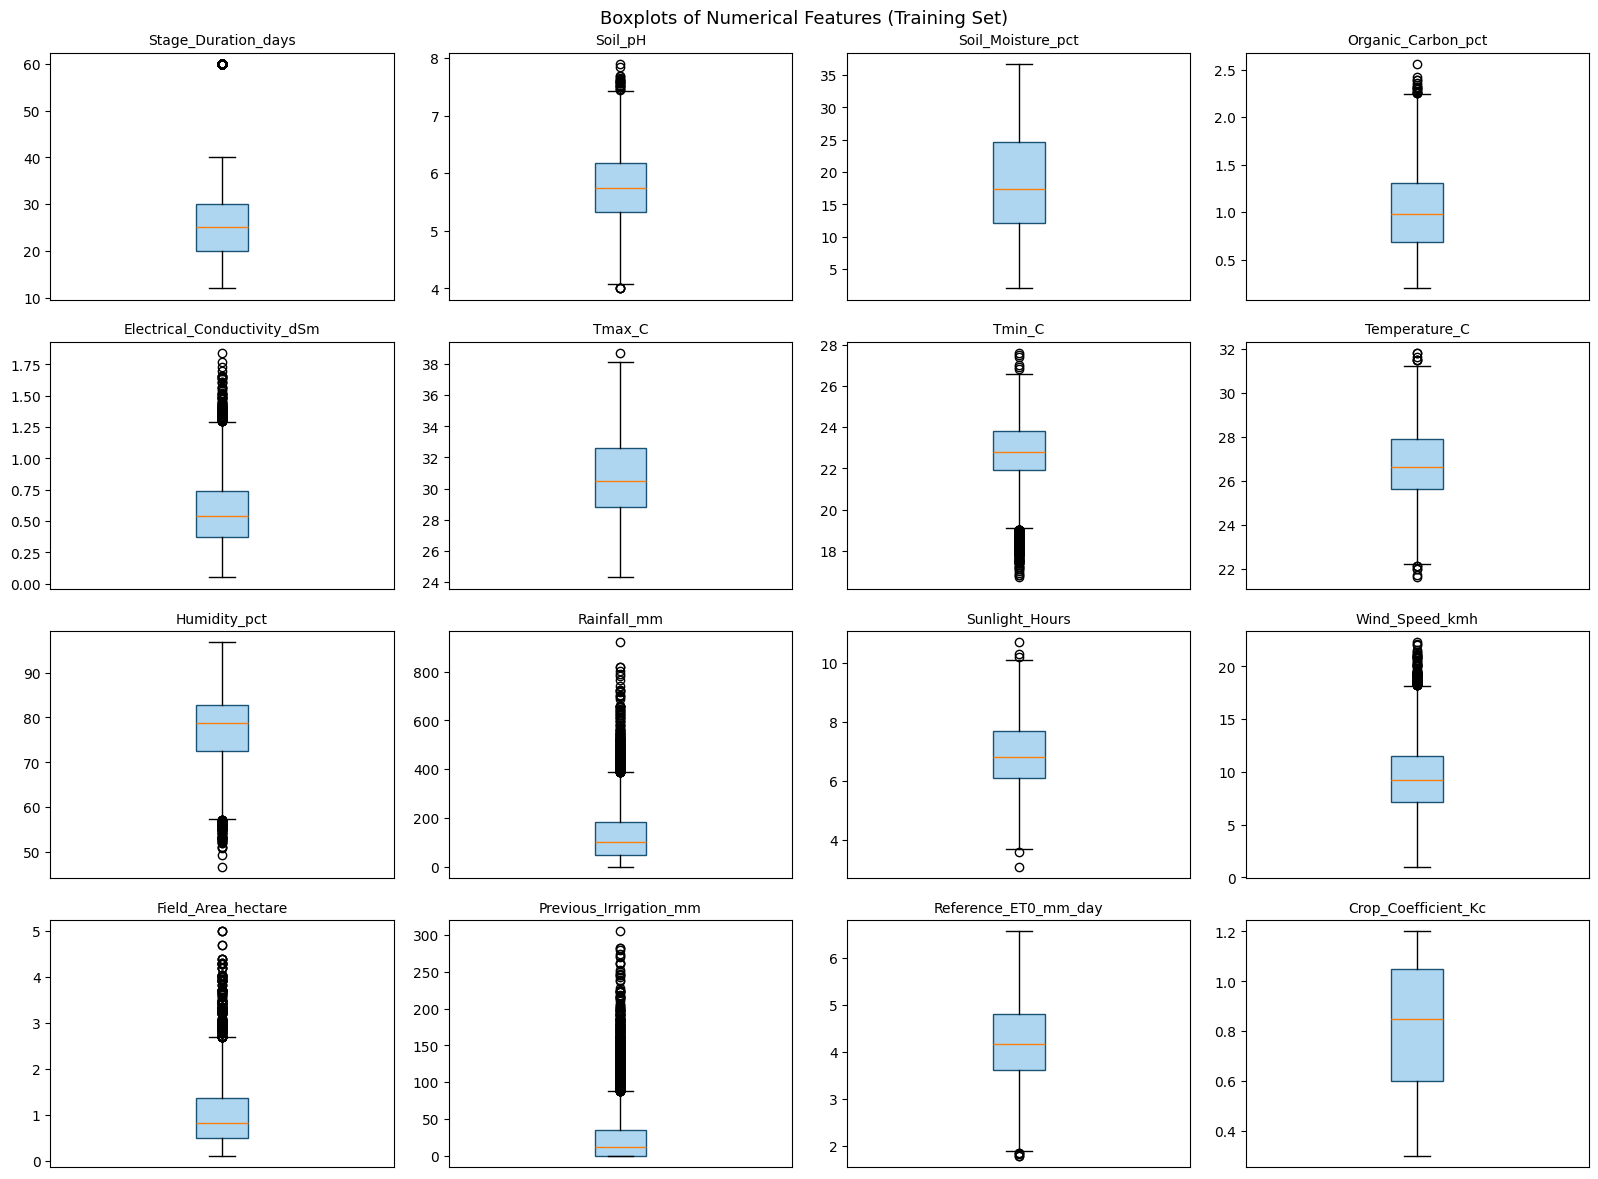

In [13]:
# ── Boxplots for visual outlier detection ──────────────────────────────────
# FIX (NEW STEP): Boxplots were missing in the original notebook
n_cols = 4
n_rows = (len(quan) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(quan):
    axes[i].boxplot(X_train[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#AED6F1', color='#1A5276'))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticks([])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots of Numerical Features (Training Set)', fontsize=13)
plt.tight_layout()
plt.show()

In [14]:
def OutlierDetector(Quan, descriptive_df, data_df):
    """
    Identifies low and high outliers, returning master tables with columns organized as:
    column_name -> outlier_count -> outlier_% -> threshold -> outlier_range.
    """
    low_summary_data = []
    high_summary_data = []
    LesserOut = []
    GreaterOut = []
    total_rows = len(data_df)
    
    for columnName in Quan:
        lesser_threshold = descriptive_df.loc["Lesser", columnName]
        greater_threshold = descriptive_df.loc["Greater", columnName]
        
        # 1. Process Low Outliers
        low_vals = data_df[data_df[columnName] < lesser_threshold][columnName].tolist()
        if len(low_vals) > 0:
            LesserOut.append(columnName)
            low_min, low_max = min(low_vals), max(low_vals)
            range_str = f"[{low_min}]" if low_min == low_max else f"[{low_min} to {low_max}]"
            
            low_summary_data.append({
                "column_name": columnName,
                "outlier_count": len(low_vals),
                "outlier_%": f"{(len(low_vals) / total_rows) * 100:.2f}%",
                "lesser_threshold": lesser_threshold,
                "outlier_range": range_str
            })
            
        # 2. Process High Outliers
        high_vals = data_df[data_df[columnName] > greater_threshold][columnName].tolist()
        if len(high_vals) > 0:
            GreaterOut.append(columnName)
            high_min, high_max = min(high_vals), max(high_vals)
            range_str = f"[{high_min}]" if high_min == high_max else f"[{high_min} to {high_max}]"
            
            high_summary_data.append({
                "column_name": columnName,
                "outlier_count": len(high_vals),
                "outlier_%": f"{(len(high_vals) / total_rows) * 100:.2f}%",
                "greater_threshold": greater_threshold,
                "outlier_range": range_str
            })
            
    df_low = pd.DataFrame(low_summary_data)
    df_high = pd.DataFrame(high_summary_data)
        
    return df_low, df_high, LesserOut, GreaterOut

In [15]:
df_low_summary, df_high_summary, lesser_outliers, greater_outliers = OutlierDetector(quan, descriptive, X_train)

print("📉 LOW OUTLIERS TABLE PROFILE:")
display(df_low_summary) 

print("\n📈 HIGH OUTLIERS TABLE PROFILE:")
display(df_high_summary)

📉 LOW OUTLIERS TABLE PROFILE:


,column_name,outlier_count,outlier_%,lesser_threshold,outlier_range
0,Soil_pH,4,0.05%,4.07,[4.0]
1,Tmin_C,240,3.00%,19.05,[16.7 to 19.0]
2,Temperature_C,6,0.07%,22.15,[21.6 to 22.1]
3,Humidity_pct,77,0.96%,57.30,[46.7 to 57.2]
4,Sunlight_Hours,2,0.03%,3.70,[3.1 to 3.6]
5,Reference_ET0_mm_day,5,0.06%,1.85,[1.79 to 1.85]



📈 HIGH OUTLIERS TABLE PROFILE:


,column_name,outlier_count,outlier_%,greater_threshold,outlier_range
0,Stage_Duration_days,314,3.92%,45.0000,[60]
1,Soil_pH,22,0.27%,7.4300,[7.44 to 7.9]
2,Organic_Carbon_pct,16,0.20%,2.2400,[2.25 to 2.56]
3,Electrical_Conductivity_dSm,119,1.49%,1.2950,[1.3 to 1.84]
4,Tmax_C,1,0.01%,38.3000,[38.7]
5,Tmin_C,6,0.07%,26.6500,[26.8 to 27.6]
6,Temperature_C,6,0.07%,31.3500,[31.5 to 31.8]
7,Rainfall_mm,286,3.57%,387.5125,[387.6 to 920.4]
8,Sunlight_Hours,3,0.04%,10.1000,[10.2 to 10.7]
9,Wind_Speed_kmh,97,1.21%,18.1000,[18.2 to 22.3]


# We have outliers in our dataset, but we will not remove them. These extreme values accurately represent real-world climate variations and severe weather conditions that are entirely plausible in a real-time scenario.

In [16]:
# Check skewness for all numerical features
skewness = X_train[quan].skew().sort_values(ascending=False)
print("Skewness of Numerical Features:\n", skewness)

Skewness of Numerical Features:
 Previous_Irrigation_mm         2.256601
Rainfall_mm                    1.503064
Field_Area_hectare             1.430959
Stage_Duration_days            1.315131
Electrical_Conductivity_dSm    0.567786
Wind_Speed_kmh                 0.536826
Soil_Moisture_pct              0.424480
Organic_Carbon_pct             0.378897
Tmax_C                         0.284754
Temperature_C                  0.127380
Sunlight_Hours                 0.121776
Soil_pH                        0.120954
Reference_ET0_mm_day           0.014435
Crop_Coefficient_Kc           -0.419073
Humidity_pct                  -0.629116
Tmin_C                        -0.650782
dtype: float64


In [17]:
# Print frequency distribution for categorical columns
for col in qual:
    print(f"=== Distribution for {col} ===")
    
    # Calculate counts and percentages
    counts = X_train[col].value_counts()
    percentages = X_train[col].value_counts(normalize=True) * 100
    
    # Combine into a clean summary table
    summary = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages.round(2)})
    print(summary, "\n")


=== Distribution for District ===
              Count  Percentage (%)
District                           
Matara          396            4.95
Jaffna          381            4.76
Vavuniya        360            4.50
Kegalle         352            4.40
Galle           349            4.36
Kurunegala      346            4.32
Trincomalee     342            4.28
Ratnapura       336            4.20
Kandy           335            4.19
Gampaha         328            4.10
Kalutara        326            4.08
Batticaloa      323            4.04
Badulla         319            3.99
Puttalam        318            3.98
Matale          306            3.82
Anuradhapura    305            3.81
Nuwara Eliya    300            3.75
Hambantota      298            3.72
Monaragala      297            3.71
Mullaitivu      296            3.70
Polonnaruwa     291            3.64
Ampara          285            3.56
Mannar          280            3.50
Colombo         278            3.48
Kilinochchi     253           

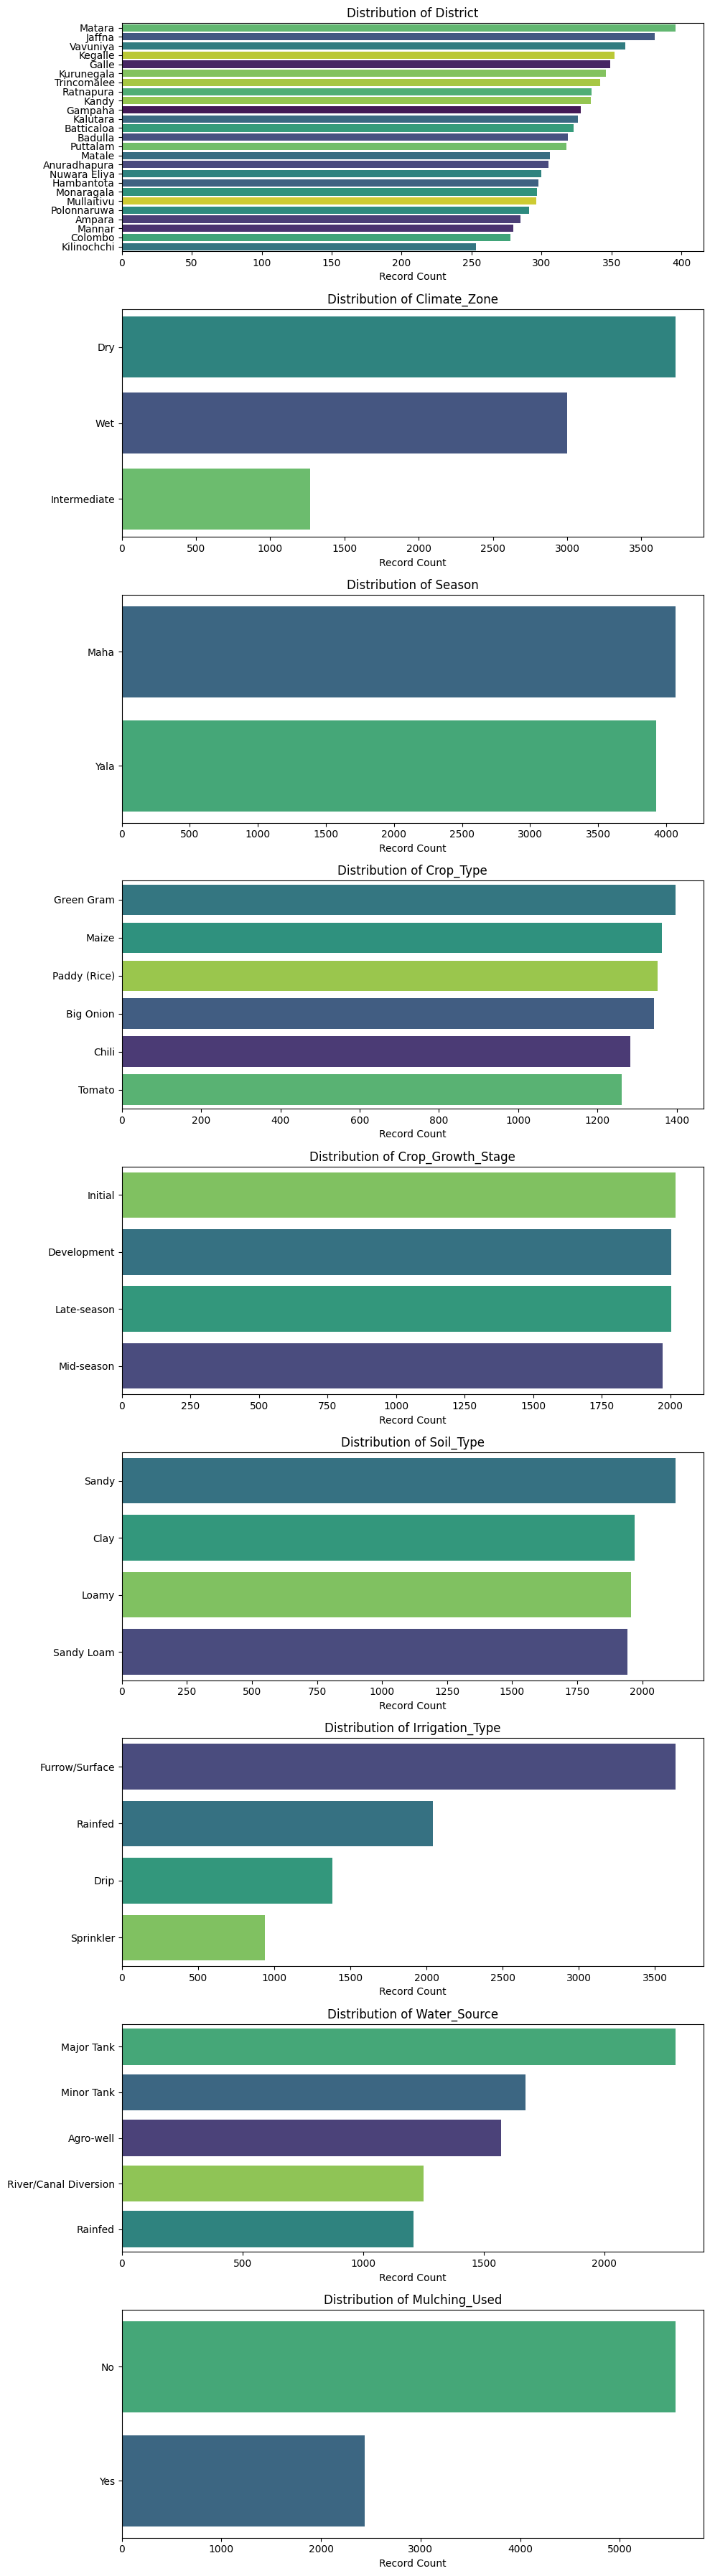

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a grid for your categorical plots
num_cols = len(qual)
fig, axes = plt.subplots(nrows=num_cols, ncols=1, figsize=(10, 4 * num_cols))

# If there is only 1 categorical column, convert axes to an array to prevent errors
if num_cols == 1:
    axes = [axes]

# Plot a countplot for each categorical feature
for i, col in enumerate(qual):
    # Added hue=col and legend=False to fix the deprecation warning
    sns.countplot(
        data=X_train, 
        y=col, 
        ax=axes[i], 
        order=X_train[col].value_counts().index, 
        palette="viridis",
        hue=col,
        legend=False
    )
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel("Record Count")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()